# 3C454.3 --- 2件/263
### 2件(正), 0件(負)
residuals = (y-fitted_line(x))/yerr

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u

nconsecutive = 3
def get_consecutive_bins(s,nconsecutive ):

  for i in range(0,len(s)-nconsecutive):
      if np.all(s[i:i+nconsecutive] > 1):
        #   print(i)
        #   print(s[i:i+nconsecutive])
        #   print('---')
          return i
      
  return -1

# logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
logpar_init = LogParabola1D(
  amplitude = 0.000016494113774149846,
  x_0 = 9.482855296727278,
  alpha = -0.5677548858840729,
  beta = 0.1071613245072173)

### initialize a linear fitter ###
# fit = fitting.TRFLSQFitter()
fit = fitting.DogBoxLSQFitter()

# t0 = Table.read('data/3C454.3_allsed_7d_min11.ecsv')
t0 = Table.read('data/3C454.3_allsed_14d_min11.ecsv')
# t = Table.read('data/PKS1510-089_allsed_14d_min11.ecsv')
# t = Table.read('data/S20109+22_allsed_14d_min11.ecsv')
# t0 = Table.read('data/Mrk421_allsed_14d_min11.ecsv')


nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
t = t0[nonzero_mask]


obsdates=np.unique(t['tstart'].data).tolist()
n_detected_peaks = 0
for idx, obsdate in enumerate(obsdates):
  print(idx, ': obsdate',obsdate)
  # if idx ==182:
  # if idx ==204 or idx == 232 or idx ==240:
  # S20109+22_allsed_14d_min11.ecsv
  # if idx ==1 or idx==8 or idx ==10 or idx ==11 or idx ==26 or idx ==28 or idx ==34 or idx ==37 or idx ==54:
  # if idx == 12 or idx ==15 or idx ==24 or idx ==25 or idx ==48 or idx ==101 or idx ==108 or idx ==127 or idx ==132 or idx ==152 or idx ==163 or idx ==164 or idx ==173 or idx ==190 or idx ==204:
  #    continue
  mask = (t['tstart']==obsdate)
  x = t[mask]['e_ref']
  y = t[mask]['e2dnde']
  yerr = t[mask]['e2dnde_err']
  ### fit the data with the fitter ###
  logpar_init.amplitude.value=x[1]*1.0e-8
  fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
  residuals = (y-fitted_line(x))/yerr
  peakbininit = get_consecutive_bins(residuals,nconsecutive)
  if peakbininit > 0:
      # print('peakbininit',peakbininit)
      # plt.plot(range(peakbininit, nbins),s[i+peakbininit:i+nbins], label='obs'+str(j), marker='o',linestyle='')
      # plt.plot(range(peakbininit, peakbininit+nconsecutive),s[i+peakbininit:i+peakbininit+3], label='obs'+str(j), marker='o',linestyle='-')
      n_detected_peaks += 1

print('Number of detected peaks:',n_detected_peaks)

0 : obsdate 54682.65603222185
1 : obsdate 54696.65603222185
2 : obsdate 54710.65603222185
3 : obsdate 54724.65603222185
4 : obsdate 54738.65603222185
5 : obsdate 54752.65603222185
6 : obsdate 54766.65603222185
7 : obsdate 54780.65603222185
8 : obsdate 54794.65603222185
9 : obsdate 54808.65603222185
10 : obsdate 54822.65603222185
11 : obsdate 54836.65603222185
12 : obsdate 54850.65603222185
13 : obsdate 54934.65603222185
14 : obsdate 54948.65603222185
15 : obsdate 54962.65603222185
16 : obsdate 54976.65603222185
17 : obsdate 54990.65603222185
18 : obsdate 55004.65603222185
19 : obsdate 55018.65603222185
20 : obsdate 55032.65603222185
21 : obsdate 55046.65603222185
22 : obsdate 55060.65603222185
23 : obsdate 55074.65603222185
24 : obsdate 55088.65603222185
25 : obsdate 55102.65603222185
26 : obsdate 55116.65603222185
27 : obsdate 55130.65603222185
28 : obsdate 55144.65603222185
29 : obsdate 55158.65603222185
30 : obsdate 55172.65603222185
31 : obsdate 55186.65603222185
32 : obsdate 55200

## ピーク検出SED表示付き

0 : obsdate 54682.65603222185
1 : obsdate 54696.65603222185
2 : obsdate 54710.65603222185
3 : obsdate 54724.65603222185
4 : obsdate 54738.65603222185
5 : obsdate 54752.65603222185
6 : obsdate 54766.65603222185
7 : obsdate 54780.65603222185
8 : obsdate 54794.65603222185
9 : obsdate 54808.65603222185
10 : obsdate 54822.65603222185
11 : obsdate 54836.65603222185
12 : obsdate 54850.65603222185
13 : obsdate 54934.65603222185
14 : obsdate 54948.65603222185
15 : obsdate 54962.65603222185
16 : obsdate 54976.65603222185
17 : obsdate 54990.65603222185
18 : obsdate 55004.65603222185
19 : obsdate 55018.65603222185
20 : obsdate 55032.65603222185
21 : obsdate 55046.65603222185
22 : obsdate 55060.65603222185
23 : obsdate 55074.65603222185
24 : obsdate 55088.65603222185
25 : obsdate 55102.65603222185
26 : obsdate 55116.65603222185
27 : obsdate 55130.65603222185
28 : obsdate 55144.65603222185
29 : obsdate 55158.65603222185
30 : obsdate 55172.65603222185
31 : obsdate 55186.65603222185
32 : obsdate 55200

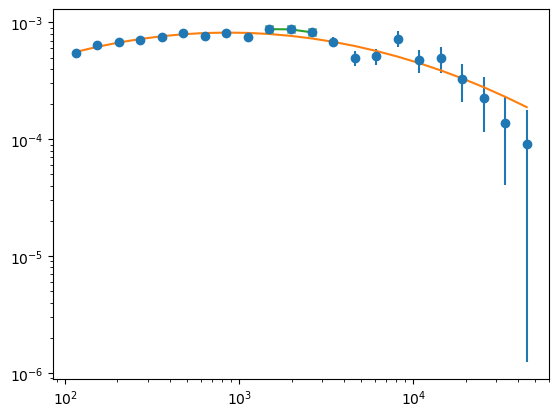

108 : obsdate 56838.65603222185
109 : obsdate 56852.65603222185
110 : obsdate 56866.65603222185
111 : obsdate 56880.65603222185
112 : obsdate 56894.65603222185
113 : obsdate 56908.65603222185
114 : obsdate 56922.65603222185
115 : obsdate 56936.65603222185
116 : obsdate 56950.65603222185
117 : obsdate 56964.65603222185
118 : obsdate 56978.65603222185
119 : obsdate 56992.65603222185
120 : obsdate 57006.65603222185
121 : obsdate 57020.65603222185
122 : obsdate 57034.65603222185
123 : obsdate 57048.65603222185
124 : obsdate 57062.65603222185
125 : obsdate 57076.65603222185
126 : obsdate 57090.65603222185
127 : obsdate 57104.65603222185
128 : obsdate 57118.65603222185
129 : obsdate 57132.65603222185
130 : obsdate 57146.65603222185
131 : obsdate 57160.65603222185
132 : obsdate 57174.65603222185
133 : obsdate 57188.65603222185
134 : obsdate 57202.65603222185
135 : obsdate 57216.65603222185
136 : obsdate 57230.65603222185
137 : obsdate 57244.65603222185
138 : obsdate 57258.65603222185
139 : ob

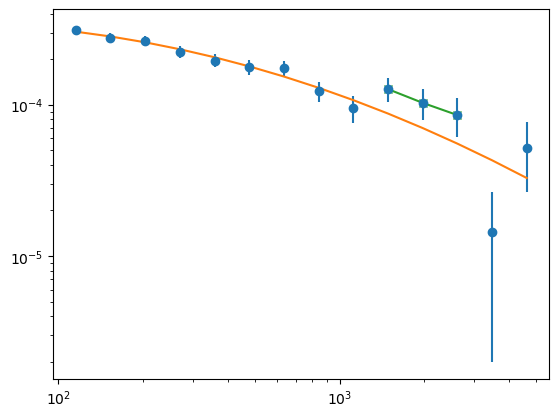

151 : obsdate 57440.65603222185
152 : obsdate 57454.65603222185
153 : obsdate 57468.65603222185
154 : obsdate 57482.65603222185
155 : obsdate 57496.65603222185
156 : obsdate 57510.65603222185
157 : obsdate 57524.65603222185
158 : obsdate 57538.65603222185
159 : obsdate 57552.65603222185
160 : obsdate 57566.65603222185
161 : obsdate 57580.65603222185
162 : obsdate 57594.65603222185
163 : obsdate 57608.65603222185
164 : obsdate 57622.65603222185
165 : obsdate 57636.65603222185
166 : obsdate 57650.65603222185
167 : obsdate 57664.65603222185
168 : obsdate 57678.65603222185
169 : obsdate 57692.65603222185
170 : obsdate 57706.65603222185
171 : obsdate 57720.65603222185
172 : obsdate 57734.65603222185
173 : obsdate 57748.65603222185
174 : obsdate 57762.65603222185
175 : obsdate 57776.65603222185
176 : obsdate 57790.65603222185
177 : obsdate 57804.65603222185
178 : obsdate 57818.65603222185
179 : obsdate 57832.65603222185
180 : obsdate 57846.65603222185
181 : obsdate 57860.65603222185
182 : ob

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u

nconsecutive = 3
def get_consecutive_bins(s,nconsecutive ):

  for i in range(0,len(s)-nconsecutive):
      if np.all(s[i:i+nconsecutive] > 1):
        #   print(i)
        #   print(s[i:i+nconsecutive])
        #   print('---')
          return i
      
  return -1

# logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
logpar_init = LogParabola1D(
  amplitude = 0.000016494113774149846,
  x_0 = 9.482855296727278,
  alpha = -0.5677548858840729,
  beta = 0.1071613245072173)

### initialize a linear fitter ###
# fit = fitting.TRFLSQFitter()
fit = fitting.DogBoxLSQFitter()

### Read the data ###
t0 = Table.read('data/3C454.3_allsed_14d_min11.ecsv')
nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
t = t0[nonzero_mask]

### MJDごとに処理 ###
obsdates=np.unique(t['tstart'].data).tolist()
n_detected_peaks = 0
for idx, obsdate in enumerate(obsdates):
  print(idx, ': obsdate',obsdate)
  mask = (t['tstart']==obsdate)
  x = t[mask]['e_ref']
  y = t[mask]['e2dnde']
  yerr = t[mask]['e2dnde_err']
  ### fit the data with the fitter ###
  logpar_init.amplitude.value=x[1]*1.0e-8
  fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
  residuals = (y-fitted_line(x))/yerr
  peakbininit = get_consecutive_bins(residuals,nconsecutive)
  nbins = len(x)
  if peakbininit > 0:
      # print('peakbininit',peakbininit)
      plt.errorbar(x,y,yerr=yerr, label='obs'+str(idx), marker='o',linestyle='')
      plt.plot(x,fitted_line(x),'-')
      plt.plot(x[peakbininit:peakbininit+nconsecutive],
               y[peakbininit:peakbininit+nconsecutive], label='obs'+str(idx), marker='x',linestyle='-')
      n_detected_peaks += 1
      plt.xscale('log')
      plt.yscale('log')
      plt.show()

print('Number of detected peaks:',n_detected_peaks)

# Mrk421 --- 5件/402
### 5件(正), 1件(負)


0 : obsdate 54682.65603222185
1 : obsdate 54696.65603222185
2 : obsdate 54710.65603222185
3 : obsdate 54724.65603222185
4 : obsdate 54738.65603222185
5 : obsdate 54752.65603222185
6 : obsdate 54766.65603222185
7 : obsdate 54780.65603222185
8 : obsdate 54794.65603222185
9 : obsdate 54808.65603222185
10 : obsdate 54822.65603222185
11 : obsdate 54836.65603222185
12 : obsdate 54850.65603222185
13 : obsdate 54864.65603222185
14 : obsdate 54878.65603222185
15 : obsdate 54920.65603222185
16 : obsdate 54934.65603222185
17 : obsdate 54948.65603222185
18 : obsdate 54962.65603222185
19 : obsdate 54976.65603222185
20 : obsdate 54990.65603222185
21 : obsdate 55004.65603222185
22 : obsdate 55018.65603222185
23 : obsdate 55032.65603222185
24 : obsdate 55046.65603222185
25 : obsdate 55060.65603222185
26 : obsdate 55074.65603222185
27 : obsdate 55088.65603222185
28 : obsdate 55102.65603222185
29 : obsdate 55116.65603222185
30 : obsdate 55130.65603222185
31 : obsdate 55144.65603222185
32 : obsdate 55158

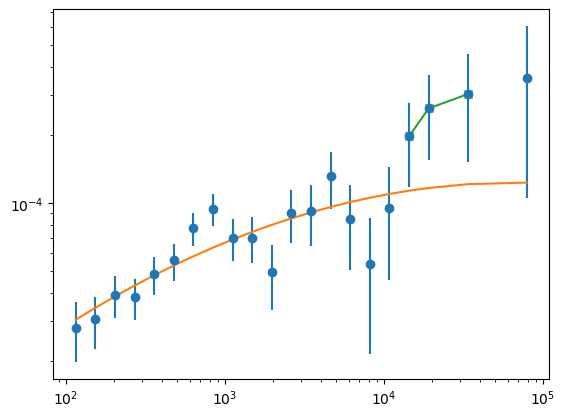

102 : obsdate 56180.65603222185
103 : obsdate 56194.65603222185
104 : obsdate 56208.65603222185
105 : obsdate 56222.65603222185
106 : obsdate 56236.65603222185
107 : obsdate 56250.65603222185
108 : obsdate 56264.65603222185
109 : obsdate 56278.65603222185
110 : obsdate 56292.65603222185
111 : obsdate 56306.65603222185
112 : obsdate 56320.65603222185
113 : obsdate 56334.65603222185
114 : obsdate 56348.65603222185
115 : obsdate 56362.65603222185
116 : obsdate 56376.65603222185
117 : obsdate 56390.65603222185
118 : obsdate 56404.65603222185
119 : obsdate 56418.65603222185
120 : obsdate 56432.65603222185
121 : obsdate 56446.65603222185
122 : obsdate 56460.65603222185
123 : obsdate 56474.65603222185
124 : obsdate 56488.65603222185
125 : obsdate 56502.65603222185
126 : obsdate 56516.65603222185
127 : obsdate 56530.65603222185
128 : obsdate 56544.65603222185
129 : obsdate 56558.65603222185
130 : obsdate 56572.65603222185
131 : obsdate 56586.65603222185
132 : obsdate 56600.65603222185
133 : ob

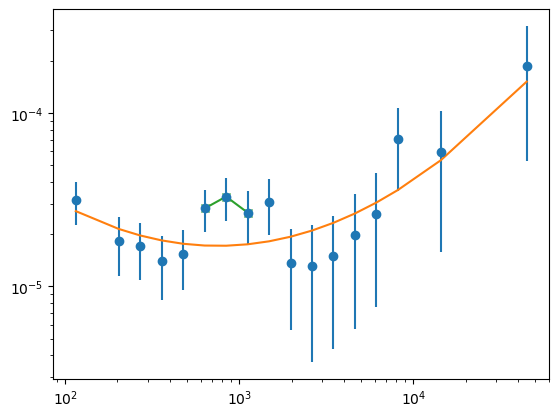

196 : obsdate 57524.65603222185
197 : obsdate 57538.65603222185
198 : obsdate 57552.65603222185
199 : obsdate 57566.65603222185
200 : obsdate 57580.65603222185
201 : obsdate 57594.65603222185
202 : obsdate 57608.65603222185
203 : obsdate 57622.65603222185
204 : obsdate 57678.65603222185
205 : obsdate 57692.65603222185
206 : obsdate 57706.65603222185
207 : obsdate 57720.65603222185
208 : obsdate 57734.65603222185
209 : obsdate 57748.65603222185
210 : obsdate 57762.65603222185
211 : obsdate 57776.65603222185
212 : obsdate 57790.65603222185
213 : obsdate 57804.65603222185
214 : obsdate 57818.65603222185
215 : obsdate 57832.65603222185
216 : obsdate 57846.65603222185


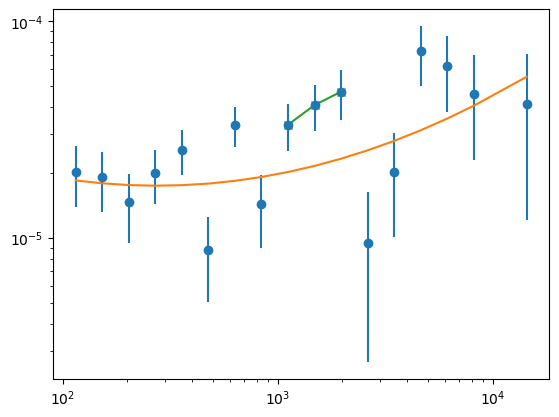

217 : obsdate 57860.65603222185
218 : obsdate 57874.65603222185
219 : obsdate 57888.65603222185
220 : obsdate 57902.65603222185
221 : obsdate 57916.65603222185
222 : obsdate 57930.65603222185
223 : obsdate 57944.65603222185
224 : obsdate 57958.65603222185
225 : obsdate 57972.65603222185
226 : obsdate 57986.65603222185
227 : obsdate 58000.65603222185
228 : obsdate 58014.65603222185
229 : obsdate 58028.65603222185
230 : obsdate 58042.65603222185
231 : obsdate 58056.65603222185
232 : obsdate 58070.65603222185
233 : obsdate 58084.65603222185
234 : obsdate 58098.65603222185
235 : obsdate 58112.65603222185
236 : obsdate 58126.65603222185
237 : obsdate 58140.65603222185
238 : obsdate 58154.65603222185
239 : obsdate 58168.65603222185
240 : obsdate 58182.65603222185
241 : obsdate 58238.65603222185
242 : obsdate 58252.65603222185
243 : obsdate 58266.65603222185
244 : obsdate 58280.65603222185
245 : obsdate 58322.65603222185
246 : obsdate 58336.65603222185
247 : obsdate 58364.65603222185
248 : ob

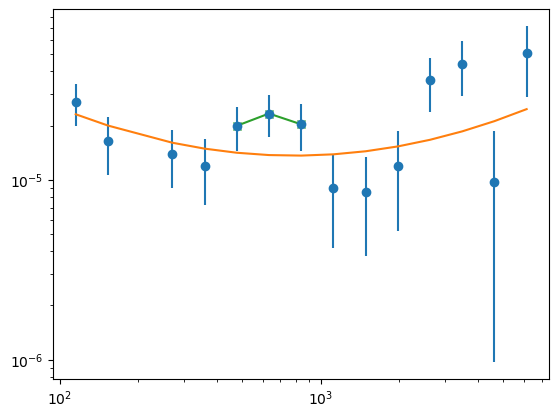

252 : obsdate 58448.65603222185
253 : obsdate 58462.65603222185
254 : obsdate 58476.65603222185
255 : obsdate 58490.65603222185
256 : obsdate 58504.65603222185
257 : obsdate 58532.65603222185
258 : obsdate 58546.65603222185
259 : obsdate 58560.65603222185
260 : obsdate 58574.65603222185
261 : obsdate 58588.65603222185
262 : obsdate 58602.65603222185
263 : obsdate 58616.65603222185
264 : obsdate 58630.65603222185
265 : obsdate 58644.65603222185
266 : obsdate 58658.65603222185
267 : obsdate 58672.65603222185
268 : obsdate 58686.65603222185
269 : obsdate 58700.65603222185
270 : obsdate 58714.65603222185
271 : obsdate 58728.65603222185
272 : obsdate 58742.65603222185
273 : obsdate 58756.65603222185
274 : obsdate 58770.65603222185
275 : obsdate 58784.65603222185
276 : obsdate 58798.65603222185
277 : obsdate 58812.65603222185
278 : obsdate 58826.65603222185
279 : obsdate 58840.65603222185
280 : obsdate 58854.65603222185
281 : obsdate 58868.65603222185
282 : obsdate 58896.65603222185
283 : ob

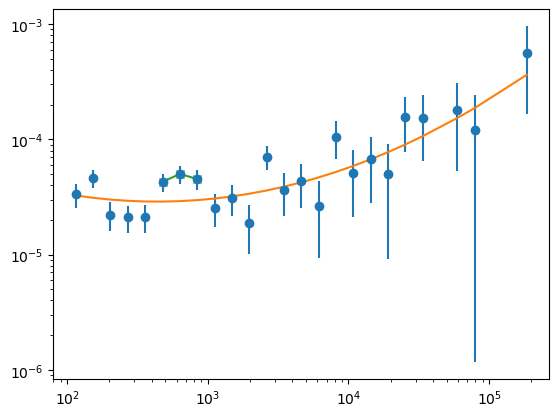

299 : obsdate 59134.65603222185
300 : obsdate 59148.65603222185
301 : obsdate 59162.65603222185
302 : obsdate 59176.65603222185
303 : obsdate 59190.65603222185
304 : obsdate 59232.65603222185
305 : obsdate 59260.65603222185
306 : obsdate 59274.65603222185
307 : obsdate 59288.65603222185
308 : obsdate 59302.65603222185
309 : obsdate 59316.65603222185
310 : obsdate 59330.65603222185
311 : obsdate 59344.65603222185
312 : obsdate 59358.65603222185
313 : obsdate 59372.65603222185
314 : obsdate 59386.65603222185
315 : obsdate 59400.65603222185
316 : obsdate 59414.65603222185
317 : obsdate 59428.65603222185
318 : obsdate 59442.65603222185
319 : obsdate 59456.65603222185
320 : obsdate 59484.65603222185
321 : obsdate 59498.65603222185
322 : obsdate 59512.65603222185
323 : obsdate 59526.65603222185
324 : obsdate 59540.65603222185
325 : obsdate 59554.65603222185
326 : obsdate 59568.65603222185
327 : obsdate 59582.65603222185
328 : obsdate 59596.65603222185
329 : obsdate 59610.65603222185
330 : ob

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u

nconsecutive = 3
def get_consecutive_bins(s,nconsecutive ):

  for i in range(0,len(s)-nconsecutive):
      if np.all(s[i:i+nconsecutive] > 1):
        #   print(i)
        #   print(s[i:i+nconsecutive])
        #   print('---')
          return i
      
  return -1

# logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
logpar_init = LogParabola1D(
  amplitude = 0.000016494113774149846,
  x_0 = 9.482855296727278,
  alpha = -0.5677548858840729,
  beta = 0.1071613245072173)

### initialize a linear fitter ###
# fit = fitting.TRFLSQFitter()
fit = fitting.DogBoxLSQFitter()

### Read the data ###
t0 = Table.read('data/Mrk421_allsed_14d_min11.ecsv')
nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
t = t0[nonzero_mask]

### MJDごとに処理 ###
obsdates=np.unique(t['tstart'].data).tolist()
n_detected_peaks = 0
for idx, obsdate in enumerate(obsdates):
  print(idx, ': obsdate',obsdate)
  mask = (t['tstart']==obsdate)
  x = t[mask]['e_ref']
  y = t[mask]['e2dnde']
  yerr = t[mask]['e2dnde_err']
  ### fit the data with the fitter ###
  logpar_init.amplitude.value=x[1]*1.0e-8
  fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
  residuals = (y-fitted_line(x))/yerr
  # residuals = (fitted_line(x)-y)/yerr
  peakbininit = get_consecutive_bins(residuals,nconsecutive)
  nbins = len(x)
  if peakbininit > 0:
      # print('peakbininit',peakbininit)
      plt.errorbar(x,y,yerr=yerr, label='obs'+str(idx), marker='o',linestyle='')
      plt.plot(x,fitted_line(x),'-')
      plt.plot(x[peakbininit:peakbininit+nconsecutive],
               y[peakbininit:peakbininit+nconsecutive], label='obs'+str(idx), marker='x',linestyle='-')
      n_detected_peaks += 1
      plt.xscale('log')
      plt.yscale('log')
      plt.show()

print('Number of detected peaks:',n_detected_peaks)

## エラーSED: 0番目（Fit改良前に問題だった）

### エラーバー過大点除去後SED

16
16
        e2dnde        
    MeV / (cm2 s)     
----------------------
1.6087437845426464e-05
1.5896285758885703e-05
1.4337754694857513e-05
 9.778173319860502e-06
2.0053782298482385e-05
 7.846996111086198e-06
 1.433836394329885e-05
 1.239357027758057e-05
2.3139276173048545e-05
 7.800256842394504e-06
 4.537883686024001e-06
 5.422054702788987e-06
 1.972002880586323e-05
2.9457787565417347e-05
1.3936819563850443e-05
1.8340820436428495e-05


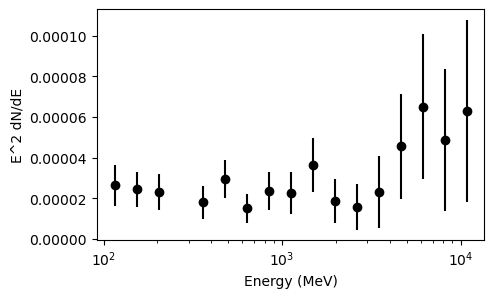

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u


# t = Table.read('data/3C454.3_allsed_7d_min11.ecsv')
# if idx ==182:
# t = Table.read('data/3C454.3_allsed_14d_min11.ecsv')
# if idx ==204 or idx == 232 or idx ==240:
# t = Table.read('data/PKS1510-089_allsed_14d_min11.ecsv')
# t = Table.read('data/S20109+22_allsed_14d_min11.ecsv')
# if idx ==1 or idx==8 or idx ==10 or idx ==11 or idx ==26 or idx ==28 or idx ==34 or idx ==37 or idx ==54:

t0 = Table.read('data/Mrk421_allsed_14d_min11.ecsv')
nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
t = t0[nonzero_mask]

obsdates=np.unique(t['tstart'].data).tolist()
obsdate = obsdates[0]
mask = (t['tstart']==obsdate)
x = t[mask]['e_ref']
y = t[mask]['e2dnde']
yerr = t[mask]['e2dnde_err']

plt.figure(figsize=(5,3))
# plt.plot(t[mask]['e_ref'],fitted_line(t[mask]['e_ref']),'-')
# plt.plot(t[mask]['e_ref'],logpar_init(t[mask]['e_ref']),'.')
plt.errorbar(t[mask]['e_ref'],t[mask  ]['e2dnde'],yerr=t[mask]['e2dnde_err'], fmt='ko')
plt.xscale('log')
plt.ylabel('E^2 dN/dE')
plt.xlabel('Energy (MeV)')

print(len(t[mask]['e2dnde']))
print(len(t[mask]['e_ref']))
# print(t[mask]['e_ref'])
# print(t[mask]['e2dnde'])
# print(t[mask]['e2dnde_err'])
print(t[mask]['e2dnde']-t[mask]['e2dnde_err'])

### 除去前SED

18
18


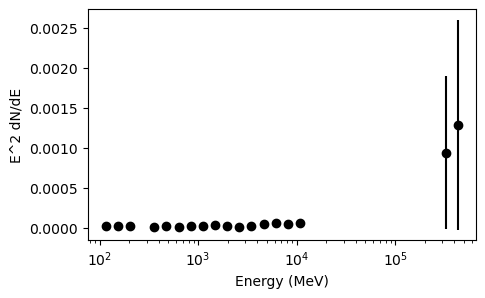

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u


t = Table.read('data/Mrk421_allsed_14d_min11.ecsv')
# nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
# t = t0[nonzero_mask]

obsdates=np.unique(t['tstart'].data).tolist()
obsdate = obsdates[0]
mask = (t['tstart']==obsdate)
x = t[mask]['e_ref']
y = t[mask]['e2dnde']
yerr = t[mask]['e2dnde_err']

plt.figure(figsize=(5,3))
# plt.plot(t[mask]['e_ref'],fitted_line(t[mask]['e_ref']),'-')
# plt.plot(t[mask]['e_ref'],logpar_init(t[mask]['e_ref']),'.')
plt.errorbar(t[mask]['e_ref'],t[mask  ]['e2dnde'],yerr=t[mask]['e2dnde_err'], fmt='ko')
plt.xscale('log')
plt.ylabel('E^2 dN/dE')
plt.xlabel('Energy (MeV)')

print(len(t[mask]['e2dnde']))
print(len(t[mask]['e_ref']))
# print(t[mask]['e_ref'])
# print(t[mask]['e2dnde'])
# print(t[mask]['e2dnde_err'])

# PKS1510-089--- 0件/213
### 0件(正), 0件(負)
### fit関数初期値調整を外したらうまく走った

In [18]:
# t = Table.read('data/PKS1510-089_allsed_14d_min11.ecsv')
# t = Table.read('data/S20109+22_allsed_14d_min11.ecsv')
# t0 = Table.read('data/Mrk421_allsed_14d_min11.ecsv')
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u

nconsecutive = 3
def get_consecutive_bins(s,nconsecutive ):

  for i in range(0,len(s)-nconsecutive):
      if np.all(s[i:i+nconsecutive] > 1):
        #   print(i)
        #   print(s[i:i+nconsecutive])
        #   print('---')
          return i
      
  return -1

# logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
logpar_init = LogParabola1D(
  amplitude = 0.000016494113774149846,
  x_0 = 9.482855296727278,
  alpha = -0.5677548858840729,
  beta = 0.1071613245072173)

### initialize a linear fitter ###
# fit = fitting.TRFLSQFitter()
fit = fitting.DogBoxLSQFitter()

### Read the data ###
t0 = Table.read('data/PKS1510-089_allsed_14d_min11.ecsv')
nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
t = t0[nonzero_mask]

### MJDごとに処理 ###
obsdates=np.unique(t['tstart'].data).tolist()
n_detected_peaks = 0
for idx, obsdate in enumerate(obsdates):
  print(idx, ': obsdate',obsdate)
  mask = (t['tstart']==obsdate)
  x = t[mask]['e_ref']
  y = t[mask]['e2dnde']
  yerr = t[mask]['e2dnde_err']
  ### fit the data with the fitter ###
  # logpar_init.amplitude.value=x[1]*1.0e-8
  fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
  residuals = (y-fitted_line(x))/yerr
  # residuals = (fitted_line(x)-y)/yerr
  peakbininit = get_consecutive_bins(residuals,nconsecutive)
  nbins = len(x)
  if peakbininit > 0:
      # print('peakbininit',peakbininit)
      plt.errorbar(x,y,yerr=yerr, label='obs'+str(idx), marker='o',linestyle='')
      plt.plot(x,fitted_line(x),'-')
      plt.plot(x[peakbininit:peakbininit+nconsecutive],
               y[peakbininit:peakbininit+nconsecutive], label='obs'+str(idx), marker='x',linestyle='-')
      n_detected_peaks += 1
      plt.xscale('log')
      plt.yscale('log')
      plt.show()

print('Number of detected peaks:',n_detected_peaks)

0 : obsdate 54696.65603222185
1 : obsdate 54710.65603222185
2 : obsdate 54724.65603222185
3 : obsdate 54752.65603222185
4 : obsdate 54766.65603222185
5 : obsdate 54822.65603222185
6 : obsdate 54836.65603222185
7 : obsdate 54850.65603222185
8 : obsdate 54864.65603222185
9 : obsdate 54878.65603222185
10 : obsdate 54892.65603222185
11 : obsdate 54906.65603222185
12 : obsdate 54920.65603222185
13 : obsdate 54934.65603222185
14 : obsdate 54948.65603222185
15 : obsdate 54962.65603222185
16 : obsdate 54976.65603222185
17 : obsdate 54990.65603222185
18 : obsdate 55004.65603222185
19 : obsdate 55018.65603222185
20 : obsdate 55032.65603222185
21 : obsdate 55046.65603222185
22 : obsdate 55060.65603222185
23 : obsdate 55088.65603222185
24 : obsdate 55102.65603222185
25 : obsdate 55116.65603222185
26 : obsdate 55130.65603222185
27 : obsdate 55144.65603222185
28 : obsdate 55158.65603222185
29 : obsdate 55172.65603222185
30 : obsdate 55186.65603222185
31 : obsdate 55200.65603222185
32 : obsdate 55228

## エラーSED:
### 29番目SED(初期値調整除去前に問題になったSED)

Text(0.5, 0, 'Energy (MeV)')

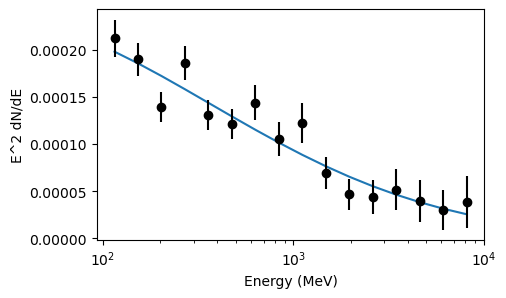

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u

nconsecutive = 3
def get_consecutive_bins(s,nconsecutive ):

  for i in range(0,len(s)-nconsecutive+1):
      if np.all(s[i:i+nconsecutive] > 1):
        #   print(i)
        #   print(s[i:i+nconsecutive])
        #   print('---')
          return i
      
  return -1

# logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
logpar_init = LogParabola1D(
  amplitude = 0.000016494113774149846,
  x_0 = 9.482855296727278,
  alpha = -0.5677548858840729,
  beta = 0.1071613245072173)

### initialize a linear fitter ###
# fit = fitting.TRFLSQFitter()
fit = fitting.DogBoxLSQFitter()

### Read the data ###
t0 = Table.read('data/PKS1510-089_allsed_14d_min11.ecsv')
nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
t = t0[nonzero_mask]

### MJDごとに処理 ###
obsdates=np.unique(t['tstart'].data).tolist()

obsdate = obsdates[29]
mask = (t['tstart']==obsdate)
x = t[mask]['e_ref']
y = t[mask]['e2dnde']
yerr = t[mask]['e2dnde_err']
### fit the data with the fitter ###
fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
# fitted_line = fit(logpar_init, x,y, maxiter=200)
residuals = (y-fitted_line(x))/yerr
peakbininit = get_consecutive_bins(residuals,nconsecutive)
if peakbininit>0:
  print('peak detected at: ',peakbininit)

residuals = (fitted_line(x)-y)/yerr
peakbininit = get_consecutive_bins(residuals,nconsecutive)
if peakbininit>0:
  print('dip detected at: ',peakbininit)

plt.figure(figsize=(5,3))
plt.plot(t[mask]['e_ref'],fitted_line(t[mask]['e_ref']),'-')
# plt.plot(t[mask]['e_ref'],logpar_init(t[mask]['e_ref']),'.')
plt.errorbar(t[mask]['e_ref'],t[mask]['e2dnde'],yerr=t[mask]['e2dnde_err'], fmt='ko')
plt.xscale('log')
plt.ylabel('E^2 dN/dE')
plt.xlabel('Energy (MeV)')
